<a href="https://colab.research.google.com/github/SergeiVKalinin/MSE_Fall_2026/blob/main/Module%202/Homework_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Homework 3 for the Fall 2026 Course "Machine Learning for Materials Science", University of Tennessee Knoxville, Department of Materials Science and Engineering.

- Instructor Sergei V. Kalinin

- The atoms data set is gracefully provided by Prof. Rampi Ramprasad, Georgia Instutute of Technology

**Please add student name and date**

# Exploring Trees


# Task: Decision Trees — Greedy Search, Global Search, and Learned Representations

In this problem, you will investigate what a decision tree is actually doing rather than treating it as a black-box classifier.We will use a simple two-dimensional classification problem consisting of two overlapping anisotropic Gaussian distributions. Class 0 is elongated vertically, whereas Class 1 is elongated horizontally. Because the two distributions have the same center, no single axis-aligned split separates them well.

Throughout the problem, we restrict the tree to only six possible binary decisions defined by the 25th, 50th, and 75th percentiles of the two coordinates. This makes the complete space of shallow trees small enough that we can compare the greedy CART strategy with exhaustive global search.

The task has three subtasks:

1. **Build a greedy decision tree and understand how CART makes local decisions.**
2. **Enumerate all possible depth-3 trees and compare local versus global optimization.**
3. **Study trees as ensembles, compressed models, and learned descriptors.**

Run the following cell first to generate the data. **Do not change the random seeds.**


In [ ]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ------------------------------------------------------------
# Generate training data
# ------------------------------------------------------------

cov0 = np.array([[0.10, 0.00],
                 [0.00, 1.20]])

cov1 = np.array([[1.20, 0.00],
                 [0.00, 0.10]])

rng = np.random.default_rng(17)

X0 = rng.multivariate_normal([0, 0], cov0, 200)
X1 = rng.multivariate_normal([0, 0], cov1, 200)

X_train = np.vstack([X0, X1])
y_train = np.array([0]*200 + [1]*200)

idx = rng.permutation(len(y_train))
X_train = X_train[idx]
y_train = y_train[idx]

# ------------------------------------------------------------
# Generate independent test data
# ------------------------------------------------------------

rng = np.random.default_rng(18)

X0_test = rng.multivariate_normal([0, 0], cov0, 2000)
X1_test = rng.multivariate_normal([0, 0], cov1, 2000)

X_test = np.vstack([X0_test, X1_test])
y_test = np.array([0]*2000 + [1]*2000)

idx = rng.permutation(len(y_test))
X_test = X_test[idx]
y_test = y_test[idx]

# ------------------------------------------------------------
# Define the six allowed split rules
# Thresholds are determined ONLY from the training data
# ------------------------------------------------------------

qx25, qx50, qx75 = np.quantile(X_train[:, 0], [0.25, 0.50, 0.75])
qy25, qy50, qy75 = np.quantile(X_train[:, 1], [0.25, 0.50, 0.75])

rules = [
    ("x < q25", 0, qx25),
    ("x < q50", 0, qx50),
    ("x < q75", 0, qx75),
    ("y < q25", 1, qy25),
    ("y < q50", 1, qy50),
    ("y < q75", 1, qy75),
]

print("Allowed rules:")
for i, (name, feature, threshold) in enumerate(rules):
    print(f"{i}: {name:8s}    threshold = {threshold:.4f}")

# ------------------------------------------------------------
# Visualize the training data
# ------------------------------------------------------------

plt.figure(figsize=(6, 6))
plt.scatter(X_train[y_train == 0, 0],
            X_train[y_train == 0, 1],
            s=20, alpha=0.7, label="Class 0")
plt.scatter(X_train[y_train == 1, 0],
            X_train[y_train == 1, 1],
            s=20, alpha=0.7, label="Class 1")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Training data")
plt.legend()
plt.show()


## Subtask 1 — Build a Greedy Decision Tree

We first reproduce the basic logic of CART.

For binary classification, define the Gini impurity of a node as

$$G = 1 - \sum_k p_k^2$$

where $p_k$ is the fraction of samples belonging to class $k$.

For a candidate split, define the Gini gain as

$$\Delta G = G_{\mathrm{parent}} - \frac{N_L}{N}G_L - \frac{N_R}{N}G_R$$

where $N_L$ and $N_R$ are the numbers of samples in the left and right child nodes.

### 1A. Examine the six possible root decisions

For each of the six allowed rules:

1. Divide the training data into left and right children.
2. Report the numbers of Class-0 and Class-1 samples in each child.
3. Calculate the Gini impurity of each child.
4. Calculate the weighted Gini impurity after the split.
5. Calculate the Gini gain.

Display your results in a table.

**Question:** Which rule would a greedy CART algorithm select as the root?

### 1B. Construct a greedy depth-3 tree

Write your own greedy decision-tree algorithm using only the six allowed rules.

At every node:

1. Consider all six rules.
2. Discard a rule if it sends all samples to one child.
3. Calculate the Gini gain.
4. Choose the rule with the largest Gini gain.
5. Continue recursively until a maximum depth of 3 is reached.

Each terminal leaf should predict the majority class of the training samples in that leaf. If the two classes are exactly tied, predict Class 0.

Do **not** use `sklearn.tree.DecisionTreeClassifier` for this part.

Report:

- the complete tree structure;
- the class composition of every leaf;
- training accuracy;
- test accuracy;
- number of terminal leaves;
- mean path length from the root to a leaf, weighted by the number of training samples reaching each leaf.

Plot the resulting decision regions together with the training data.

### 1C. Impurity versus accuracy

Find at least one split in your fitted tree for which the split decreases Gini impurity but does not change the majority-class prediction of the parent region.

Explain briefly why minimizing Gini impurity is not the same as directly maximizing classification accuracy.


In [ ]:

def gini(y):
    # TODO
    pass

def evaluate_rule(X, y, rule):
    # TODO
    pass

def build_greedy_tree(X, y, rules, depth=0, max_depth=3):
    # TODO
    pass


## Subtask 2 — Exhaustive Search: Is the Greedy Tree Globally Optimal?

A greedy tree chooses the best decision **at the current node**. This does not necessarily mean that the resulting sequence of decisions is globally optimal. Consider an ordered, full binary tree of maximum depth 3:

$$T = (r_0,r_1,r_2,r_3,r_4,r_5,r_6)$$

Here $r_0$ is the root, $r_1$ and $r_2$ are the decisions at depth 1, and $r_3,\ldots,r_6$ are the decisions at depth 2. Each $r_i$ can be any of the six allowed rules.

### 2A. Enumerate model space

Calculate how many ordered full depth-3 trees can be constructed from the six rules.

Enumerate all of them. For every tree:

1. Route every training sample through the tree.
2. Assign every terminal leaf its majority training class.
3. Calculate training accuracy.

For this enumeration, it is acceptable for a tree to contain redundant decisions or empty terminal branches.

Plot the distribution of training accuracies over the complete population of trees. Mark the greedy-tree accuracy on the same plot.

Report:

- number of trees evaluated;
- minimum training accuracy;
- median training accuracy;
- maximum training accuracy;
- number of trees achieving the maximum;
- fraction of all trees that outperform the greedy tree.

### 2B. Compare greedy and global optimization

Identify at least one globally optimal tree for which all eight terminal leaves contain at least one training observation.

Report its seven decisions.

Compare the following quantities for the greedy tree and the globally optimal tree:

- root rule;
- Gini gain produced by the root;
- training accuracy;
- test accuracy.

Explain the result.

**Question:** Can a decision that produces very little immediate reduction in impurity nevertheless be the correct first step in a better sequence of decisions?

### 2C. Training versus test performance

Evaluate every enumerated tree on the independent test set. Leaf labels must still be determined **only from the training data**.

Create a scatter plot of test accuracy versus training accuracy:

$$A_{\mathrm{test}}\;\mathrm{versus}\;A_{\mathrm{train}}$$

Mark:

- the greedy tree;
- one globally training-optimal tree;
- the tree having the largest observed test accuracy.

Answer:

1. Does the training-optimal tree also have the largest test accuracy?
2. Is it legitimate to select the final model by looking for the tree with the highest test accuracy?
3. What role should a validation set play if model selection is required?


In [ ]:

import itertools

# Each full depth-3 tree contains 7 internal nodes.
# Each internal node can use any of the 6 rules.

all_trees = itertools.product(range(6), repeat=7)

# TODO:
# Enumerate tree definitions, route samples, assign leaf labels
# from training data, and calculate train/test accuracy.


## Subtask 3 — Forests, Compression, and Learned Representations

The same tree can be interpreted as:

1. a predictive model;
2. one member of an ensemble;
3. a compressed description of the labels;
4. a transformation from the original features to a learned discrete representation.

### 3A. Bootstrap trees and a restricted random forest

Generate 200 bootstrap datasets from the original training data. Each bootstrap dataset contains 400 samples drawn **with replacement**.

Use:

```python
rng = np.random.default_rng(19)
```

For each bootstrap dataset:

1. Fit the greedy depth-3 tree from Subtask 1.
2. Keep the same six thresholds calculated from the original training set.
3. Evaluate the tree on the common test set.
4. Record the root rule.

Plot the distribution of test accuracies of the 200 trees. Report the frequency of each root rule.

Then combine all 200 trees using majority voting and report the ensemble test accuracy.

Discuss:

- How stable is the tree structure under changes in training data?
- Does the ensemble outperform the individual trees substantially?
- Why can an ensemble of strongly correlated trees provide relatively little improvement?

As an optional comparison, fit a standard `sklearn` depth-3 CART tree and a standard depth-3 random forest in which arbitrary thresholds are allowed.

### 3B. Decision trees as compression models

Suppose the 400 binary training labels are stored directly. Use

$$L_{\mathrm{raw}} = 400\;\mathrm{bits}$$

For a binary tree with $I$ internal nodes and $I+1$ leaves, use

$$L_{\mathrm{model}} = 6I + 2$$

If the tree makes $m$ training errors, define the residual description length as

$$L_{\mathrm{residual}} = \log_2(N+1) + \log_2\binom{N}{m}$$

with $N=400$.

The total description length is

$$L_{\mathrm{total}} = L_{\mathrm{model}} + L_{\mathrm{residual}}$$

and the compression ratio is

$$CR = \frac{L_{\mathrm{raw}}}{L_{\mathrm{total}}}$$

Calculate these quantities for:

1. your greedy tree;
2. a globally optimal tree from Subtask 2.

Discuss:

**Question:** Is the most accurate tree necessarily the tree that gives the shortest overall description of the data?

### 3C. Decision trees as learned descriptors

Originally, each sample is represented by

$$\mathbf{x} = (x,y)$$

After passing through a tree, the sample can instead be represented by its sequence of binary decisions,

$$z_{\mathrm{path}} = (L,R,L,\ldots)$$

or simply by its terminal leaf identity,

$$z_{\mathrm{leaf}} = \ell$$

For both your greedy tree and a globally optimal tree, calculate:

- number of occupied leaves;
- maximum path length;
- mean path length;
- minimum fixed number of bits required to encode leaf identity;
- entropy of the empirical leaf-occupancy distribution.

For leaf probabilities $p_\ell$, use

$$H_{\mathrm{leaf}} = -\sum_\ell p_\ell\log_2 p_\ell$$

For a forest with $M$ trees, a sample can instead be represented by

$$\mathbf{z}(\mathbf{x}) = [\ell_1(\mathbf{x}),\ell_2(\mathbf{x}),\ldots,\ell_M(\mathbf{x})]$$

In a short paragraph, discuss:

**Question:** Is a decision tree only a classifier, or can it also be viewed as a learned transformation from the original feature vector to a new discrete representation?


In [ ]:

# TODO: Subtask 3A
# Bootstrap 200 greedy trees and construct a majority-vote ensemble.

# TODO: Subtask 3B
# Compute description lengths and compression ratios.

# TODO: Subtask 3C
# Compute leaf-based representation metrics.


# Let's classify atoms!

In [1]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib import cm

import pandas as pd
import seaborn as sns

## Import Atom Dataset

In [2]:
!gdown https://drive.google.com/uc?id=1SygYRQ4Iom2ZP7dANIyay7NIoCra2bE1

Downloading...
From: https://drive.google.com/uc?id=1SygYRQ4Iom2ZP7dANIyay7NIoCra2bE1
To: /content/atoms.csv
100% 5.89k/5.89k [00:00<00:00, 14.8MB/s]


In [3]:
df = pd.read_csv('/content/atoms.csv')
df.head()

,Symbol,Atomic_radius,Covalent_radius,Density,Pauling_Electronegativity,Electron_affinity,First_Ionisation_Energy,Heat_Evaporation,Melting_Point,Boiling_Point,Specific_Heat,Specific_Volume,Thermal_Conductivity,Max_Oxidation_States
0,H,53,31,0.0708,2.20,72.769,1311.3,0.904,14.01,20.280,14.267,14.1,0.1815,1
1,He,31,28,0.1470,0.00,-50.000,2361.3,0.080,0.95,4.216,5.188,31.8,0.1520,2
2,Li,167,128,0.5340,0.98,59.632,519.9,148.000,553.69,1118.150,3.489,13.1,84.8000,1
3,Be,112,96,1.8480,1.57,-50.000,898.8,309.000,1551.00,3243.000,1.824,5.0,201.0000,2
4,B,87,84,2.3400,2.04,26.989,800.2,504.500,2573.00,3931.000,1.025,4.6,27.4000,3


## Simple statistical analysis

Below each markdown section, write a code that will perform the analysis and visualize the results. Feel free to use CodeAssistant in Colab or ChatGPT. If there are additional questions, please provide answers in the markdown fields below the code section/output. While many Python libraries can be used for this analysis, Seaborn can be the most convenient.

1. Create a histogram of the melting point distribution

2. Create the boxplot of the melting and boiling points

3. Use the Standard Scaler in the scikit-learn to normalize the values in the table and create the boxplot of all variables. Hint: drop the non-numeric column. In the markdown field, comment on what information does boxplot provide.

Answer 3:

4. Explore other ways to represent statistical distribution of a single parameter.

## Correlation analysis

5. Plot the correlation between the melting point and boiling point and between covalent radius and density. In the markdown section, rationalize the observations.

Answer 5:

6. Create a heatmap of correlation coefficients between the entries in the table. Find by direct examination the groups of parameters with strongest positive and strongest negative correlations. In the markdown section, rationalize the observations.

Answer 6:

7. Create a pair distribution plot of Atomic_radius, Covalent_radius,Pauling_Electronegativity and First_Ionisation_Energy

---



## Simple Regression

8. Perform a linear fit between the boiling temperature and melting temperature and between specific heat and melting point. Provide the values of fit coefficients and units.

# Explore the classification

Let's create a simple data set that will allow us to explore several simple classifiers


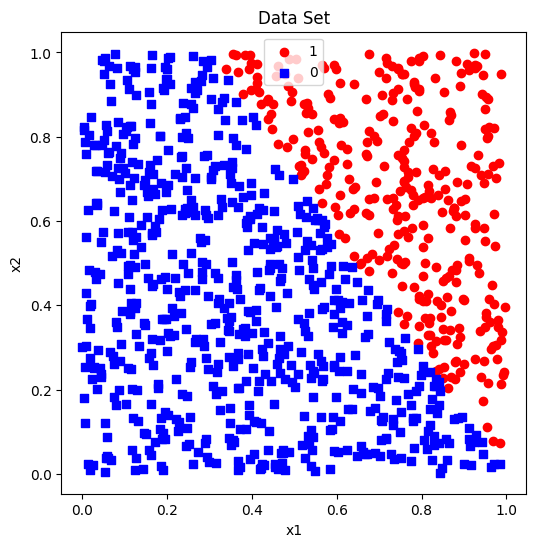

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Generate features
n = 1000
x1 = np.random.uniform(0, 1, n)
x2 = np.random.uniform(0, 1, n)

# Calculate targets
y = (x1 + 0.7*x2 >= 1).astype(int)

# Plot the data
plt.figure(figsize=(6, 6))
plt.scatter(x1[y == 1], x2[y == 1], c='red', marker='o', label='1')
plt.scatter(x1[y == 0], x2[y == 0], c='blue', marker='s', label='0')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend()
plt.title('Data Set')
plt.show()

X1 = np.column_stack((x1, x2))
y1 = y

9. Experiment with the different classifiers for this data set:
- Create train-test split (say 30-70)
- Build the decision tree classifier
- Explore the outputs if you vary the depth of the tree
- And see how the performance changes if you change the number of points in the data set (say compare 100 and 1000)
- Visualize the decision surface (use examples from class Colab)

10. Do the same for the perceptron classifier

11. Do the same for the logistics regression classifier
- Experiment with the regularization parameters
- Can you plot the data for small number of points but also add class probabilities?

# Bring in the LLM!

12. Here, we are going to use the ChatGPT to summarize the data about elements, and then use the information from our data set in the beginning of the notebook as features. This will be non-trivial process, because rather then working with the already provided data, we will have a chance to create our data set and discover that formats matter. Several steps:

- We want to get from ChatGPT table of the electronic properties of elements in the form where first column is element symbol, and the second column is metal/dielectric/semiconductor. It may take a few iterations - since ChatGPT will tend to introduce other forms of classification (e.g. metalloid). You can ask it early on to use Python form, that you can just cut and paste into Colab.

- The dataframe df in the beginning of the notebook that has feature vectors, and the dataframe you will get from ChatGPT will have different number of elements. You will have to pick the ones that are common to both. The easy way to do it is to convert corresponding columns to lists, and then do something like this: new_list = list(set(list1) & set(list2)). Then pick from both dataframes only rows that have elements present in the new_list

- One thing you will discover is that this operation will give you empty list the first time you do it. Try to identify the problem by examining the element symbols, and consider using operation like df['Symbol'] = df['Symbol'].str.strip()

- With these, build classifier with the allbproperties from df as features and metal/dielectric/semiconductor as target. What is the precision?

- Calculate confusion matrix

- Pick 2 random features that you think are most predictive and plot decision boundary in feature space.  